In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [11]:
# load data
kasios_df = pd.read_csv('/content/drive/MyDrive/visual_analytics_project/kasios_spectral_statistics.csv')
pipit_df = pd.read_csv('/content/drive/MyDrive/visual_analytics_project/pipit_spectral_statistics.csv')

# preview data
print("Kasios Spectral Statistics:")
print(kasios_df.head())
print("Verified Blue Pipit Spectral Statistics:")
print(pipit_df.head())

Kasios Spectral Statistics:
   File ID  Peak Frequency  Mean Frequency  Total Magnitude  Spectral Entropy
0        1       51.822224     5512.494909        7687801.5         18.454443
1        2     4288.784859     5512.491902        9538686.0         17.897905
2        3     4394.404145     5512.494333       10372071.0         19.040829
3        4     4337.492803     5512.491281        8050211.5         18.242828
4        5     1569.282430     5512.488088        2244361.8         14.817022
Verified Blue Pipit Spectral Statistics:
   File ID  Peak Frequency  Mean Frequency  Total Magnitude  Spectral Entropy
0   402254      319.940476     5512.351190        265120.94         14.654433
1   406171     5010.655117     5512.488727       4201662.00         17.748180
2   405901       63.013962     5512.307100        105327.09         12.778466
3   405548      117.916594     5512.469765       1757438.90         16.749039
4   401782     4180.031668     5512.465317       5610210.00         16.12

In [14]:
# function for t-test comparison between two groups
def compare_groups(group1, group2, feature):
    kasios_values = group1[feature].dropna().values
    verified_values = group2[feature].dropna().values

    t_stat, p_value = stats.ttest_ind(kasios_values, verified_values)
    return t_stat, p_value

In [15]:
# apply t-test function
t_stat_peak, p_value_peak = compare_groups(kasios_df, pipit_df, 'Peak Frequency')
t_stat_mean, p_value_mean = compare_groups(kasios_df, pipit_df, 'Mean Frequency')
t_stat_entropy, p_value_entropy = compare_groups(kasios_df, pipit_df, 'Spectral Entropy')

print(f"T-statistic (Kasios vs Verified Pipit - Peak Frequency): {t_stat_peak}, P-value: {p_value_peak}")
print(f"T-statistic (Kasios vs Verified Pipit - Mean Frequency): {t_stat_mean}, P-value: {p_value_mean}")
print(f"T-statistic (Kasios vs Verified Pipit - Spectral Entropy): {t_stat_entropy}, P-value: {p_value_entropy}")

T-statistic (Kasios vs Verified Pipit - Peak Frequency): 0.6278838377336483, P-value: 0.5307999043021527
T-statistic (Kasios vs Verified Pipit - Mean Frequency): 2.425791902771563, P-value: 0.01616694677856593
T-statistic (Kasios vs Verified Pipit - Spectral Entropy): 2.358185912476876, P-value: 0.019334277841751988


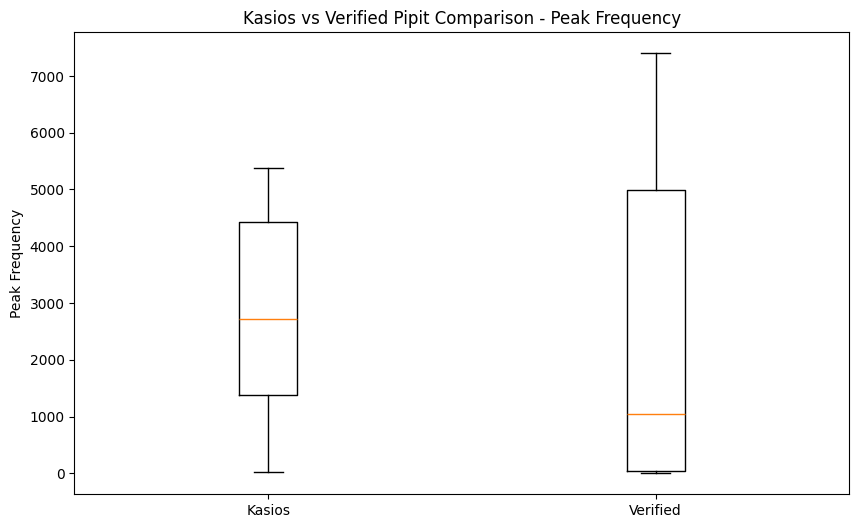

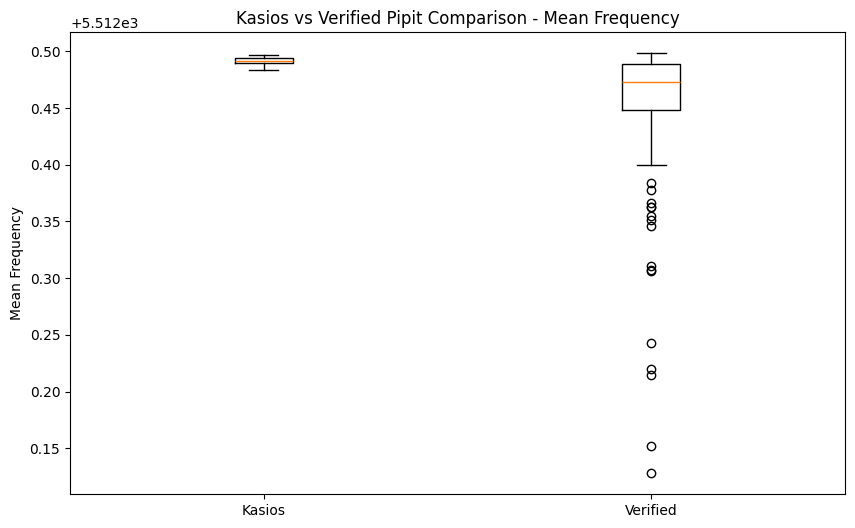

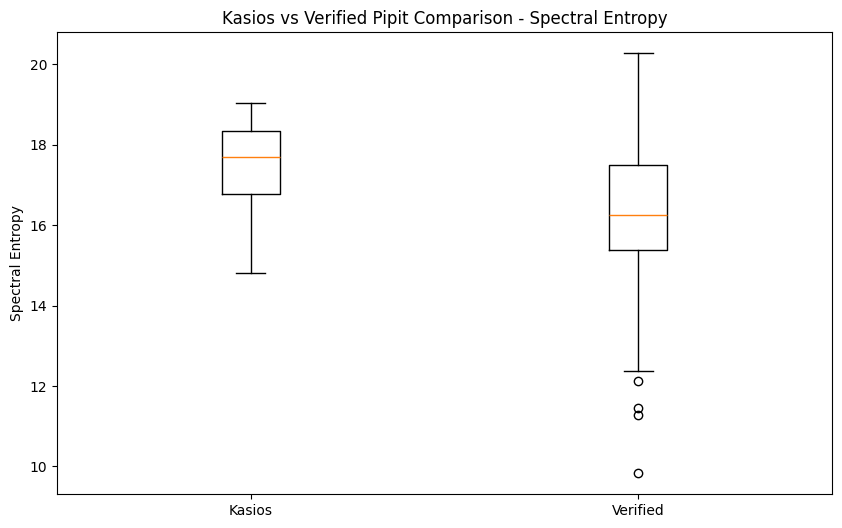

In [16]:
# boxplot
def plot_comparison(group1, group2, feature, title):
    plt.figure(figsize=(10,6))
    plt.boxplot([group1[feature], group2[feature]])
    plt.xticks([1, 2], ['Kasios', 'Verified'])
    plt.title(f"{title} Comparison - {feature}")
    plt.ylabel(feature)
    plt.show()

plot_comparison(kasios_df, pipit_df, 'Peak Frequency', 'Kasios vs Verified Pipit')
plot_comparison(kasios_df, pipit_df, 'Mean Frequency', 'Kasios vs Verified Pipit')
plot_comparison(kasios_df, pipit_df, 'Spectral Entropy', 'Kasios vs Verified Pipit')


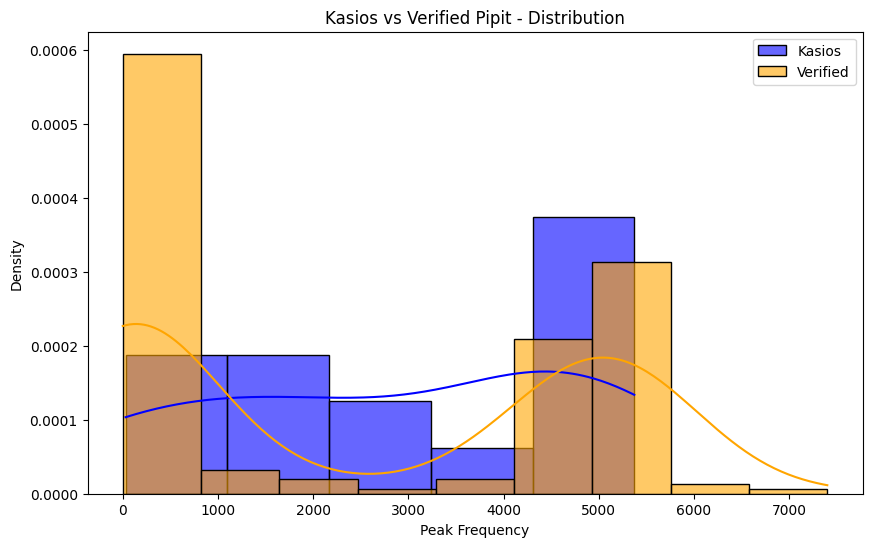

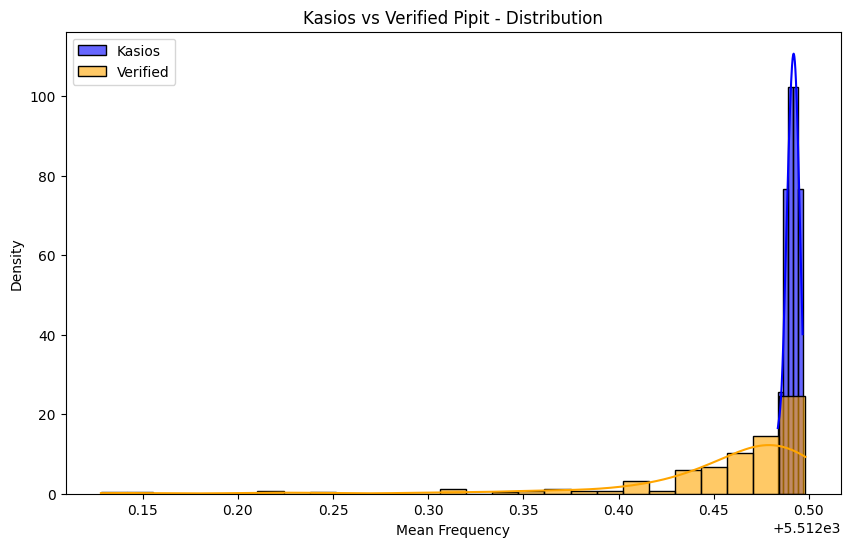

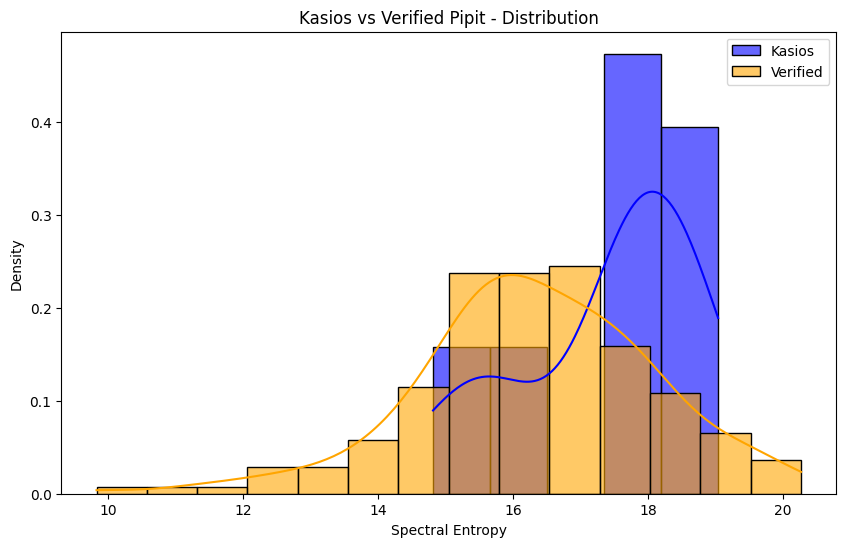

In [17]:
# histogram
def plot_distribution(group1, group2, feature, title):
    plt.figure(figsize=(10, 6))
    sns.histplot(group1[feature], color='blue', kde=True, stat='density', label='Kasios', alpha=0.6)
    sns.histplot(group2[feature], color='orange', kde=True, stat='density', label='Verified', alpha=0.6)
    plt.title(f"{title} - Distribution")
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

plot_distribution(kasios_df, pipit_df, 'Peak Frequency', 'Kasios vs Verified Pipit')
plot_distribution(kasios_df, pipit_df, 'Mean Frequency', 'Kasios vs Verified Pipit')
plot_distribution(kasios_df, pipit_df, 'Spectral Entropy', 'Kasios vs Verified Pipit')


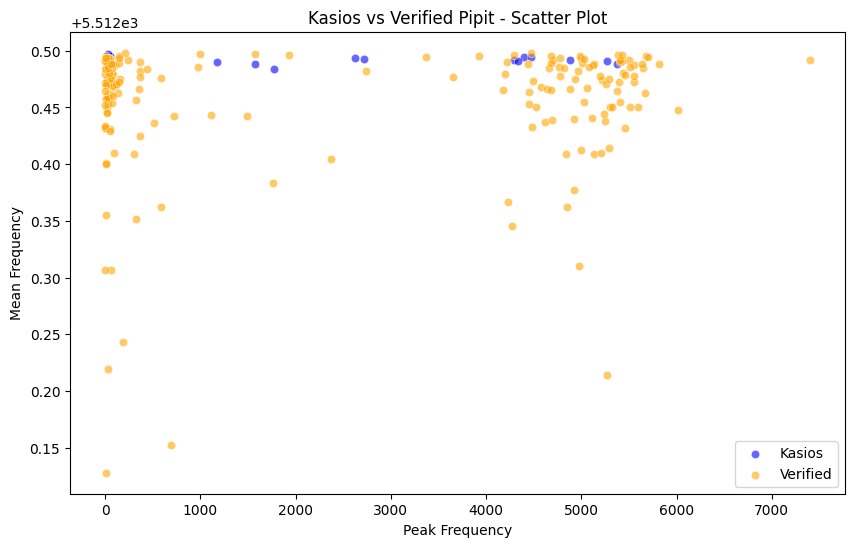

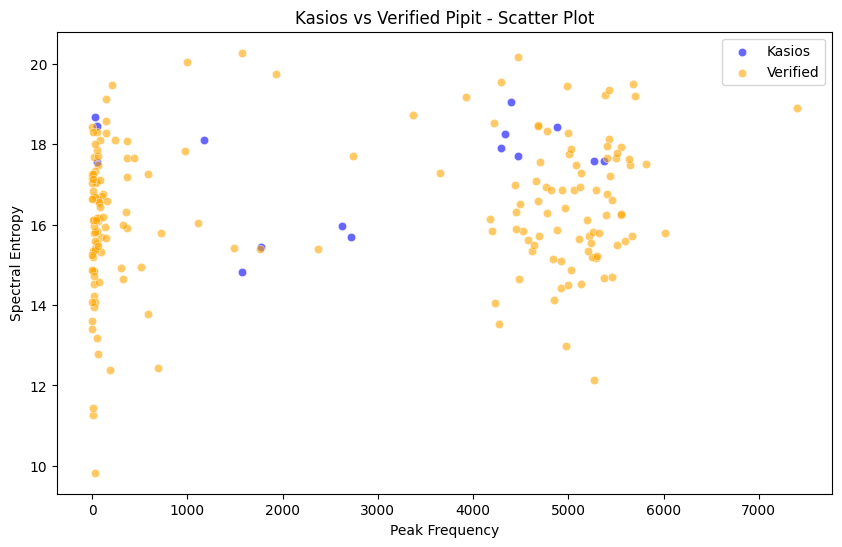

In [18]:
# scatter plot
def plot_scatter(group1, group2, feature1, feature2, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=group1[feature1], y=group1[feature2], color='blue', label='Kasios', alpha=0.6)
    sns.scatterplot(x=group2[feature1], y=group2[feature2], color='orange', label='Verified', alpha=0.6)
    plt.title(f"{title} - Scatter Plot")
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.legend()
    plt.show()

# peak frequency vs mean frequency
plot_scatter(kasios_df, pipit_df, 'Peak Frequency', 'Mean Frequency', 'Kasios vs Verified Pipit')

# peak frequency vs spectral entropy
plot_scatter(kasios_df, pipit_df, 'Peak Frequency', 'Spectral Entropy', 'Kasios vs Verified Pipit')
